# Phase 2: Preprocessing & Vectorization

**Project:** YouTube Toxic Comment Detector (`ai-nlp`)

**Goals (AGENTS.md Phase 2):**
- Regex cleaning (URLs, emojis, special characters)
- Tokenization, stopwords, lemmatization (NLTK)
- TF-IDF and CountVectorizer (Esencial)
- Target: **Safe vs Toxic** (`IsToxic`)

## Environment (`uv`)

From repository root **`.`**:

```bash
uv sync
uv run jupyter notebook notebooks/phase2_preprocessing_vectorization.ipynb
```

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.evaluation.phase1_audit import BINARY_TARGET
from src.features.phase2_text_pipeline import clean_text_regex, process_text
from src.pipeline.phase2_build_processed import build_phase2_dataset
from src.utils.execution_log import log_event

REPORT_DIR = ROOT / "reports/phase2"
PROCESSED_CSV = ROOT / "data/processed/youtoxic_phase2.csv"
LOG_PATH = ROOT / "logs/execution.log"

sns.set_theme(style="whitegrid")
log_event("Phase 2 notebook started", phase="2", log_path=LOG_PATH)

## 1. Text cleaning samples

In [2]:
samples = [
    "Great video!!! https://spam.com @hater",
    "You are the worst " + chr(0x1F620) + " idiot",
    "Thanks for the clear explanation.",
]
rows = []
for s in samples:
    clean, proc = process_text(s)
    rows.append({"original": s, "CleanText": clean, "ProcessedText": proc})
sample_df = pd.DataFrame(rows)
display(sample_df)

,original,CleanText,ProcessedText
0,Great video!!! https://spam.com @hater,great video,great video
1,You are the worst 😠 idiot,you are the worst idiot,worst idiot
2,Thanks for the clear explanation.,thanks for the clear explanation,thanks clear explanation


## 2. Build processed dataset & vectorizers

In [3]:
summary = build_phase2_dataset()
print(json.dumps(summary, indent=2))

{
  "phase": 2,
  "source": "youtoxic_english_1000.csv",
  "processed_csv": "data/processed/youtoxic_phase2.csv",
  "n_rows": 1000,
  "n_train": 800,
  "n_test": 200,
  "target": "IsToxic",
  "empty_processed_text": 0,
  "vectorizers": {
    "tfidf": "data/processed/vectorizers/tfidf_vectorizer.joblib",
    "count": "data/processed/vectorizers/count_vectorizer.joblib"
  },
  "vectorizer_stats": {
    "tfidf": {
      "max_features": 5000,
      "ngram_range": [
        1,
        2
      ],
      "vocabulary_size": 2079
    },
    "count": {
      "max_features": 5000,
      "ngram_range": [
        1,
        2
      ],
      "vocabulary_size": 2079
    }
  },
  "tfidf_train_shape": [
    800,
    2079
  ],
  "count_train_shape": [
    800,
    2079
  ],
  "augmentation_note": "Deferred to training phase (Phase 3/4); synonym aug available in src.features.augmentation"
}


## 3. Inspect processed data

In [4]:
df = pd.read_csv(PROCESSED_CSV)
print(f"Shape: {df.shape}")
print(df["split"].value_counts())
print(f"Empty ProcessedText: {(df['ProcessedText'].astype(str).str.len() == 0).sum()}")
df.head()

Shape: (1000, 5)
split
train    800
test     200
Name: count, dtype: int64
Empty ProcessedText: 0


,Text,CleanText,ProcessedText,IsToxic,split
0,If only people would just take a step back and...,if only people would just take a step back and...,people would take step back make case wasnt an...,0,train
1,Law enforcement is not trained to shoot to app...,law enforcement is not trained to shoot to app...,law enforcement trained shoot apprehend traine...,1,train
2,\nDont you reckon them 'black lives matter' ba...,dont you reckon them black lives matter banner...,dont reckon black life matter banner held whit...,1,train
3,There are a very large number of people who do...,there are a very large number of people who do...,large number people like police officer called...,0,test
4,"The Arab dude is absolutely right, he should h...",the arab dude is absolutely right he should ha...,arab dude absolutely right shot extra time sho...,0,train


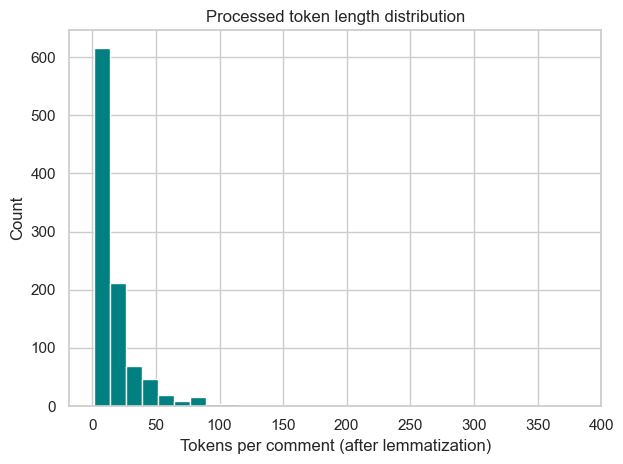

Saved: /Users/miraekang/proyectos/ai-nlp/reports/phase2/token_length_hist.png


In [5]:
fig, ax = plt.subplots()
df["ProcessedText"].str.split().str.len().hist(bins=30, ax=ax, color="teal", edgecolor="white")
ax.set_xlabel("Tokens per comment (after lemmatization)")
ax.set_ylabel("Count")
ax.set_title("Processed token length distribution")
plt.tight_layout()
tok_path = REPORT_DIR / "token_length_hist.png"
plt.savefig(tok_path, dpi=120)
plt.show()
print(f"Saved: {tok_path}")

## 4. Vectorizer summary (train split)

In [6]:
print("TF-IDF:", summary["vectorizer_stats"]["tfidf"])
print("Count:", summary["vectorizer_stats"]["count"])
print("Train matrix shapes — TF-IDF:", summary["tfidf_train_shape"], "Count:", summary["count_train_shape"])

TF-IDF: {'max_features': 5000, 'ngram_range': [1, 2], 'vocabulary_size': 2079}
Count: {'max_features': 5000, 'ngram_range': [1, 2], 'vocabulary_size': 2079}
Train matrix shapes — TF-IDF: [800, 2079] Count: [800, 2079]


## Conclusion

Phase 2 completed: regex + NLTK lemmatization, processed CSV, and fitted vectorizers for Phase 3 baseline training.

In [7]:
print("=" * 60)
print("PHASE 2 — KEY FINDINGS")
print("=" * 60)
print(f"Processed file: {PROCESSED_CSV}")
print(f"Rows: {summary['n_rows']} (train {summary['n_train']}, test {summary['n_test']})")
print(f"Target: {summary['target']} (Safe vs Toxic)")
print(f"Empty ProcessedText: {summary['empty_processed_text']}")
print(f"TF-IDF vocab: {summary['vectorizer_stats']['tfidf']['vocabulary_size']}")
print(f"Count vocab: {summary['vectorizer_stats']['count']['vocabulary_size']}")
print(f"Augmentation: {summary['augmentation_note']}")
print(f"Report: {ROOT / 'reports/phase2/phase2_summary.json'}")
print("=" * 60)
log_event("Phase 2 notebook completed", phase="2", log_path=LOG_PATH)

PHASE 2 — KEY FINDINGS
Processed file: /Users/miraekang/proyectos/ai-nlp/data/processed/youtoxic_phase2.csv
Rows: 1000 (train 800, test 200)
Target: IsToxic (Safe vs Toxic)
Empty ProcessedText: 0
TF-IDF vocab: 2079
Count vocab: 2079
Augmentation: Deferred to training phase (Phase 3/4); synonym aug available in src.features.augmentation
Report: /Users/miraekang/proyectos/ai-nlp/reports/phase2/phase2_summary.json
